In [56]:
import numpy as np
import matplotlib.pyplot as plt

In [74]:
lw = 3.0
colors = {
    'gd': 'tab:blue',
    'cd': 'tab:orange',
    'ssd': 'tab:green',
    'spsa': 'tab:purple',
    'rgfm': 'tab:brown',
    'ssd_hf': 'tab:olive',
    'ssd_bf': 'tab:cyan',
    'ssd_oracle': 'tab:pink',
    'ssd_sag': 'tab:gray',
}

names = {
    'gd': 'Gradient Descent',
    'cd': 'Coordiante Descent',
    'ssd': 'SSD (Fixed Step)',
    'spsa': 'SPSA',
    'rgfm': 'Random Gradient',
    'ssd_hf': 'SSD (HF)',
    'ssd_bf': 'SSD (BF)',
    'ssd_oracle': 'SSD (Oracle)',
    'ssd_sag': 'SSD (VR)',
}

def plot_results(
        file, 
        bf_ratio=0.0, 
        title='Results', 
        methods=None,
        index=None):
    plt.figure(figsize=(8,5))
    min_len = min(len(file['res'].item()[k][0]) for k in methods)
    if methods is None: methods = list(colors.keys())
    if index is None: index = 0

    for k in methods:
        color = colors[k]
        res_mean = np.mean(file['res'].item()[k], axis=0)
        res_best, res_worst = np.min(file['res'].item()[k], axis=0), np.max(file['res'].item()[k], axis=0)
        leng = len(res_mean)
        min_len = min(min_len, leng)
        t = np.arange(len(res_mean))
        if k == 'ssd_bf':
            t = (1 + bf_ratio) * t
        plt.plot(t[index:min_len], res_mean[index:min_len], label=names[k], color=color, lw=lw, alpha=0.6)
        plt.fill_between(t[index:min_len], res_best[index:min_len], res_worst[index:min_len], alpha=0.4, color=color)
    plt.yscale('log')
    plt.xlabel('Equivalent HF Function Calls', fontsize=14), plt.ylabel('HF Function value', fontsize=14), plt.legend()
    plt.title(title, fontsize=20)
    plt.xlim(index, min_len)
    plt.tight_layout()

## Worst Function in the World
We use an example function 
$$f(x; r) = \lambda ((x_1^2 + x_r^2 + \sum_{i=1}^{r-1}(x_i - x_{i+1})^2)/2 - x_1)/4.$$

We set $\lambda =20$, HF function $f(x;100)$ and LF function $f(x;2)$.

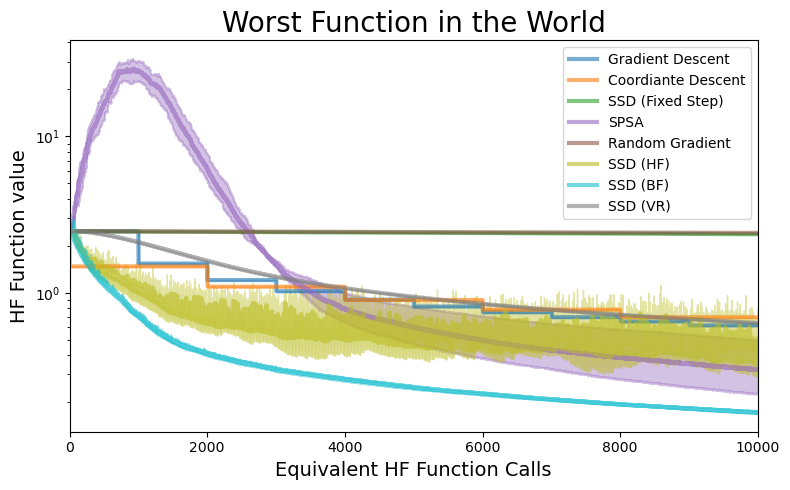

In [58]:
# Load results data
d = 1000
r1 = 100
r2 = 2
lmda = 20.0
ell = 10
c = 0.9

path = f'../results/worst/worst-d{d}-rH{r1}-rL{r2}-lmda{lmda}-ell{ell}-c{c}.npz'
file = np.load(path, allow_pickle=True)

methods = ['gd', 'cd', 'ssd', 'spsa', 'rgfm', 'ssd_hf', 'ssd_bf', 'ssd_sag']
plot_results(file, bf_ratio=0.0, title='Worst Function in the World', methods=methods)

## Black-box Kernel Ridge Regression with Low-rank Nystroem

We use dual form of the kernel ridge regression 
$$f(\mathbf{\alpha}; \tau, \mathbf{K}, \mathbf{y}) = \mathbf{\alpha}^T\mathbf{K}\mathbf{\alpha} - 2\langle \mathbf{\alpha},\mathbf{y}\rangle + \tau\lVert \mathbf{\alpha}\rVert^2.$$
We set $\tau = 0.001$, LF function with kernel matrix approximated by Nystroem method. The optimal solution for this optimization is 
$$\mathbf{\alpha}^* = (\mathbf{K}+\tau\mathbf{I})^{-1}\mathbf{y}.$$


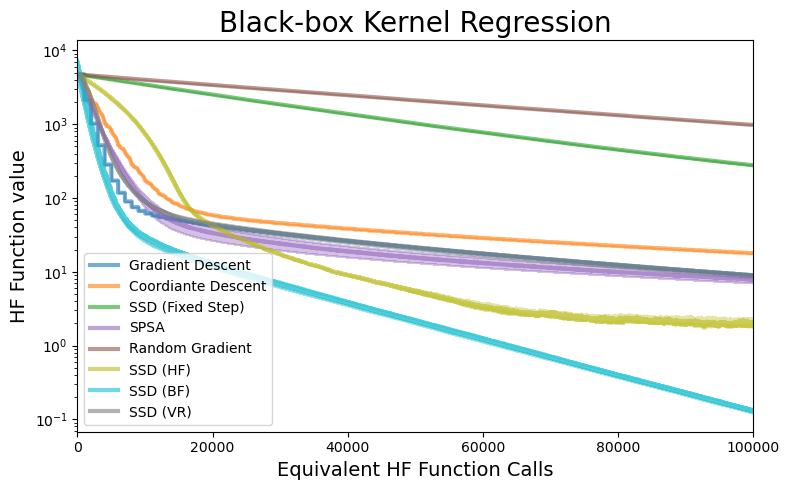

In [59]:
# Load results data
d = 1000
lr = 10
lmda = 20.0
L0 = 1.0
tau = 0.001
ell = 50
c = 0.95

path = f'../results/kernel/kernel-d{d}-lr{lr}-L0{L0}-tau{tau}-ell{ell}-c{c}.npz'
file = np.load(path, allow_pickle=True)
bf_ratio = file['bf_ratio']
methods = ['gd', 'cd', 'ssd', 'spsa', 'rgfm', 'ssd_hf', 'ssd_bf', 'ssd_sag']
plot_results(file, bf_ratio=bf_ratio, title='Black-box Kernel Regression', methods=methods)

## Black-box Adversarial Attack with Low-fidelity SVM

We consider the case of adversarial attack with black box model 
$$f(\mathbf{\delta}; y^\dagger, c, g) = \tau\cdot\text{ReLU}(\log[g(\mathbf{\delta}+\mathbf{x}^\dagger)]_{y^\dagger} - \max_{i\neq y^\dagger}\log [g(\mathbf{\delta}+\mathbf{x}^\dagger)]_i) + \lVert \mathbf{\delta}\rVert^2.$$
We set $\tau = 10.0$, $\mathbf{x}^\dagger, y^\dagger$ as the first test sample, $g(\cdot)$ is a pre-trained CNN with test accuracy $99.02\%$. The low-fidelity model is a linear logistic regression (trained on only 50 training samples) returns classification probability with accuracy $55.16\%$.

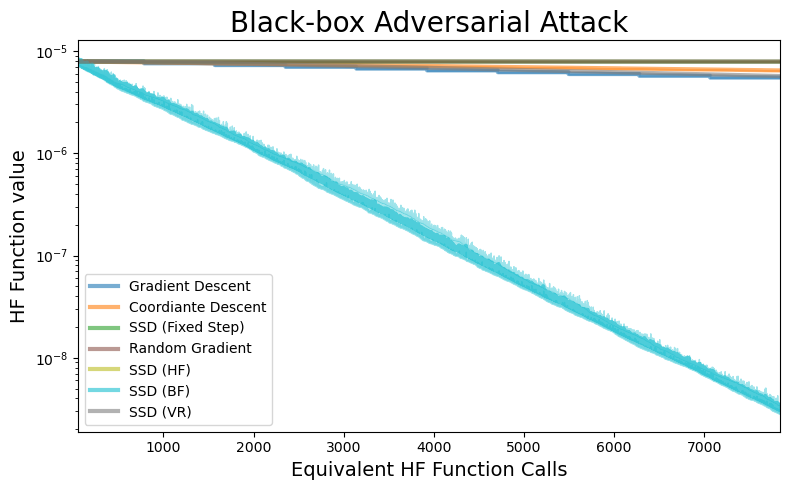

In [60]:
# Load results data
d = 784
tau = 10.0
L0 = 1.0
ell = 10
c = 0.9

path = f'../results/adversarial/adversarial-d{d}-d{d}-L0{L0}-tau{tau}-ell{ell}-c{c}.npz'
file = np.load(path, allow_pickle=True)
methods = ['gd', 'cd', 'ssd', 'rgfm', 'ssd_hf', 'ssd_bf', 'ssd_sag']
plot_results(file, bf_ratio=0.0, title='Black-box Adversarial Attack', methods=methods, index=50)

## Fine Tuning CNN on MNIST Dataset

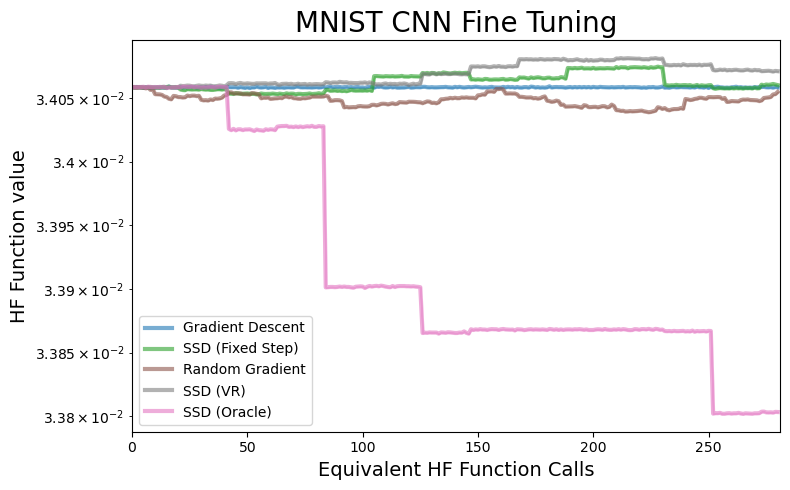

In [88]:
# Load results data
d = 280
L0 = 1.0
ell = 20
c = 0.9
sr = 0.01
linesearch_iter = 20

path = f'../results/fine-tuning/fine-tuning-d{d}-li{linesearch_iter}-sr{sr}-L0{L0}-ell{ell}-c{c}.npz'
file = np.load(path, allow_pickle=True)
bf_ratio = file['bf_ratio']
methods = ['gd', 'ssd', 'rgfm', 'ssd_sag', 'ssd_oracle']

plot_results(file, bf_ratio=bf_ratio, title='MNIST CNN Fine Tuning', methods=methods)